------------------
```markdown
# Copyright © 2025 Meysam Goodarzi
This notebook is licensed under CC BY-NC 4.0 with the following amendments:
- Individuals may use, share, and adapt this material for non-commercial purposes with attribution.
- Institutions/Companies must obtain written consent to use this material, except for nonprofits.
- Commercial use is prohibited without permission.  
Contact: analytica@meysam-goodarzi.com
```
------------------------------
❗❗❗ **IMPORTANT**❗❗❗ **Create a copy of this notebook**

In order to work with this Google Colab you need to create a copy of it. Please **DO NOT** provide your answers here. Instead, work on the copy version. To make a copy:

**Click on: File -> save a copy in drive**

Have you successfully created the copy? if yes, there must be a new tab opened in your browser. Now move to the copy and start from there!

----------------------------------------------


# Bayesian Hierarchical Models II: Advanced Topics

## Learning Objectives

By the end of this notebook, you will be able to:
1. Understand and apply **non-centered parameterization** to fix divergences
2. Build models with **crossed random effects** (non-nested hierarchies)
3. Diagnose and fix common problems in hierarchical models
4. Conduct comprehensive model diagnostics

## Recap from Part I

**Key concepts:**
- **Partial pooling:** Balance between complete pooling and no pooling
- **Shrinkage:** Small groups borrow strength from population mean
- **Random intercepts:** Group-specific baselines
- **Random slopes:** Group-specific effects

**Today's focus:** Advanced modeling techniques and diagnostics

In [1]:
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# Set random seed
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
az.style.use("arviz-darkgrid")

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## Dataset: Italian Student Performance

We'll use the same dataset from Part I, with artificially reduced samples for schools 0 and 1.

In [2]:
# Load data
df_full = pd.read_csv("https://drive.google.com/uc?id=1znf0o6-4IqQ7EtvRCZxVYtjUjBNCmZuP")
df = df_full[['school_id', 'student_id', 'math_t1', 'math_t2']].copy()

# Create school index
df['school_idx'], school_names = pd.factorize(df['school_id'])
n_schools = df['school_idx'].nunique()

# Artificially reduce samples for schools 0 and 1
np.random.seed(42)
school_0_students = df[df['school_idx'] == 0]['student_id'].values
keep_0 = np.random.choice(school_0_students, size=10, replace=False)
school_1_students = df[df['school_idx'] == 1]['student_id'].values
keep_1 = np.random.choice(school_1_students, size=20, replace=False)

df = df[
    (df['school_idx'] == 0) & (df['student_id'].isin(keep_0)) |
    (df['school_idx'] == 1) & (df['student_id'].isin(keep_1)) |
    (df['school_idx'] >= 2)
].copy()

df['school_idx'], school_names = pd.factorize(df['school_id'])
n_schools = df['school_idx'].nunique()

print(f"Dataset: {len(df)} students across {n_schools} schools")
print(f"\nSample sizes:")
print(df.groupby('school_id').size())

Dataset: 1237 students across 10 schools

Sample sizes:
school_id
57      10
60      20
141    145
262    155
426    154
458    138
499    160
812    153
881    153
946    149
dtype: int64


We also manipulate the data for school impact for educational pupose:

In [3]:
df_origin = df.copy()
# Add school-level effects to create ~15-20% of variance
# Target: school SD ≈ 0.75-0.87
np.random.seed(42)

# Create strong school effects
school_effects = np.array([0.35, -0.3, 0.25, -0.25, 0.3, -0.35, 0.4, 0.45, 0.2, -0.4])

# Apply school effects to math_t2
df['math_t2_original'] = df['math_t2'].copy()  # Save original
for school in range(n_schools):
    mask = df['school_idx'] == school
    df.loc[mask, 'math_t2'] = df.loc[mask, 'math_t2'] + school_effects[school]

print("School effects added to create stronger between-school variance")
print(f"School effects: {school_effects}")
print(f"\nNew school means:")
print(df.groupby('school_idx')['math_t2'].mean())

School effects added to create stronger between-school variance
School effects: [ 0.35 -0.3   0.25 -0.25  0.3  -0.35  0.4   0.45  0.2  -0.4 ]

New school means:
school_idx
0    7.274581
1    6.535889
2    7.243145
3    6.681362
4    7.261005
5    6.471965
6    7.462347
7    7.597510
8    7.212962
9    6.396824
Name: math_t2, dtype: float64


## The Funnel Problem and Non-Centered Parameterization

### The Challenge

Hierarchical models can suffer from **geometric problems** that make MCMC sampling difficult.

**Centered Parameterization** (what we used in Part I):
$$
\begin{aligned}
y_i &\sim \mathcal{N}(\alpha_{j[i]}, \sigma^2) \\
\alpha_j &\sim \mathcal{N}(\mu_\alpha, \sigma_\alpha^2)
\end{aligned}
$$

**Problem:** When $\sigma_\alpha$ is small (groups are similar), the posterior has a "funnel" shape:
- Wide at the top (when $\sigma_\alpha$ is large)
- Narrow "neck" at the bottom (when $\sigma_\alpha \to 0$)
- MCMC has trouble navigating this geometry → **divergences**!

**Solution:** Non-centered parameterization

### Non-Centered Parameterization

**Reparameterize** to avoid the funnel:

$$
\begin{aligned}
y_i &\sim \mathcal{N}(\mu_\alpha + \sigma_\alpha \cdot \eta_{j[i]}, \sigma^2) \\
\eta_j &\sim \mathcal{N}(0, 1)
\end{aligned}
$$

where $\alpha_j = \mu_\alpha + \sigma_\alpha \cdot \eta_j$

**Key difference:**
- $\eta_j$ always has the same scale (standard normal)
- $\sigma_\alpha$ acts as a multiplier
- Geometry doesn't change with $\sigma_\alpha$ → easier sampling!

**When to use:** When you see divergences or low ESS in hierarchical models

In [4]:
# Prepare data
school_idx = df_origin['school_idx'].values
math_t1 = df_origin['math_t1'].values
math_t2 = df_origin['math_t2'].values

print("We'll build the same model twice:")
print("1. Centered parameterization (what we used in Part I)")
print("2. Non-centered parameterization (better for difficult geometries)")

We'll build the same model twice:
1. Centered parameterization (what we used in Part I)
2. Non-centered parameterization (better for difficult geometries)


### Model 1: Centered Parameterization

In [5]:
# Centered parameterization
with pm.Model() as centered_model:
    # Hyperpriors
    mu_alpha = pm.Normal('mu_alpha', mu=0, sigma=5)
    sigma_alpha = pm.HalfCauchy('sigma_alpha', 2)

    # Common slope
    beta = pm.Normal('beta', mu=1, sigma=1)

    # Random intercepts (CENTERED)
    alpha_school = pm.Normal('alpha_school', mu=mu_alpha, sigma=sigma_alpha,
                             shape=n_schools)

    # Within-school variation
    sigma = pm.HalfCauchy('sigma', 2)

    # Linear model
    mu = alpha_school[school_idx] + beta * math_t1

    # Likelihood
    y = pm.Normal('y', mu=mu, sigma=sigma, observed=math_t2)

    # Sample
    trace_centered = pm.sample(2000, tune=1000, target_accept=0.95, chains=4,
                               cores=4,
                               random_seed=42, return_inferencedata=True)

print("\nCentered model sampling complete")
print(f"Divergences: {trace_centered.sample_stats['diverging'].sum().values}")

Output()

ERROR:pymc.stats.convergence:There were 74 divergences after tuning. Increase `target_accept` or reparameterize.



Centered model sampling complete
Divergences: 74


### Model 2: Non-Centered Parameterization

In [6]:
# Non-centered parameterization
with pm.Model() as noncentered_model:
    # Hyperpriors
    mu_alpha = pm.Normal('mu_alpha', mu=0, sigma=5)
    sigma_alpha = pm.HalfCauchy('sigma_alpha', 2)

    # Common slope
    beta = pm.Normal('beta', mu=1, sigma=1)

    # Random intercepts (NON-CENTERED)
    eta_school = pm.Normal('eta_school', mu=0, sigma=1, shape=n_schools)
    alpha_school = pm.Deterministic('alpha_school',
                                    mu_alpha + sigma_alpha * eta_school)

    # Within-school variation
    sigma = pm.HalfCauchy('sigma', 2)

    # Linear model
    mu = alpha_school[school_idx] + beta * math_t1

    # Likelihood
    y = pm.Normal('y', mu=mu, sigma=sigma, observed=math_t2)

    # Sample
    trace_noncentered = pm.sample(2000, tune=1000, target_accept=0.95,
                                  chains=4, cores=4,
                                  random_seed=42, return_inferencedata=True)

print("\nNon-centered model sampling complete")
print(f"Divergences: {trace_noncentered.sample_stats['diverging'].sum().values}")

Output()


Non-centered model sampling complete
Divergences: 0


### Compare Diagnostics

In [7]:
# Compare diagnostics
print("="*70)
print("DIAGNOSTIC COMPARISON")
print("="*70)

# Divergences
div_centered = trace_centered.sample_stats['diverging'].sum().values
div_noncentered = trace_noncentered.sample_stats['diverging'].sum().values
print(f"\nDivergences:")
print(f"  Centered:     {div_centered}")
print(f"  Non-centered: {div_noncentered}")

# ESS
ess_centered = az.ess(trace_centered, var_names=['alpha_school']).to_array().values.mean()
ess_noncentered = az.ess(trace_noncentered, var_names=['alpha_school']).to_array().values.mean()
print(f"\nEffective Sample Size (alpha_school, average):")
print(f"  Centered:     {ess_centered:.0f}")
print(f"  Non-centered: {ess_noncentered:.0f}")

# R-hat
rhat_centered = az.rhat(trace_centered, var_names=['alpha_school']).to_array().values.max()
rhat_noncentered = az.rhat(trace_noncentered, var_names=['alpha_school']).to_array().values.max()
print(f"\nR-hat (alpha_school, max):")
print(f"  Centered:     {rhat_centered:.4f}")
print(f"  Non-centered: {rhat_noncentered:.4f}")

print(f"\n" + "="*70)
print(f"CONCLUSION:")
print(f"="*70)
if div_noncentered < div_centered:
    print(f"✓ Non-centered parameterization has fewer divergences")
if ess_noncentered > ess_centered:
    print(f"✓ Non-centered parameterization has higher ESS")
print(f"\nRule of thumb: Use non-centered when sigma_alpha is small or uncertain")

DIAGNOSTIC COMPARISON

Divergences:
  Centered:     74
  Non-centered: 0

Effective Sample Size (alpha_school, average):
  Centered:     962
  Non-centered: 5886

R-hat (alpha_school, max):
  Centered:     1.0076
  Non-centered: 1.0007

CONCLUSION:
✓ Non-centered parameterization has fewer divergences
✓ Non-centered parameterization has higher ESS

Rule of thumb: Use non-centered when sigma_alpha is small or uncertain


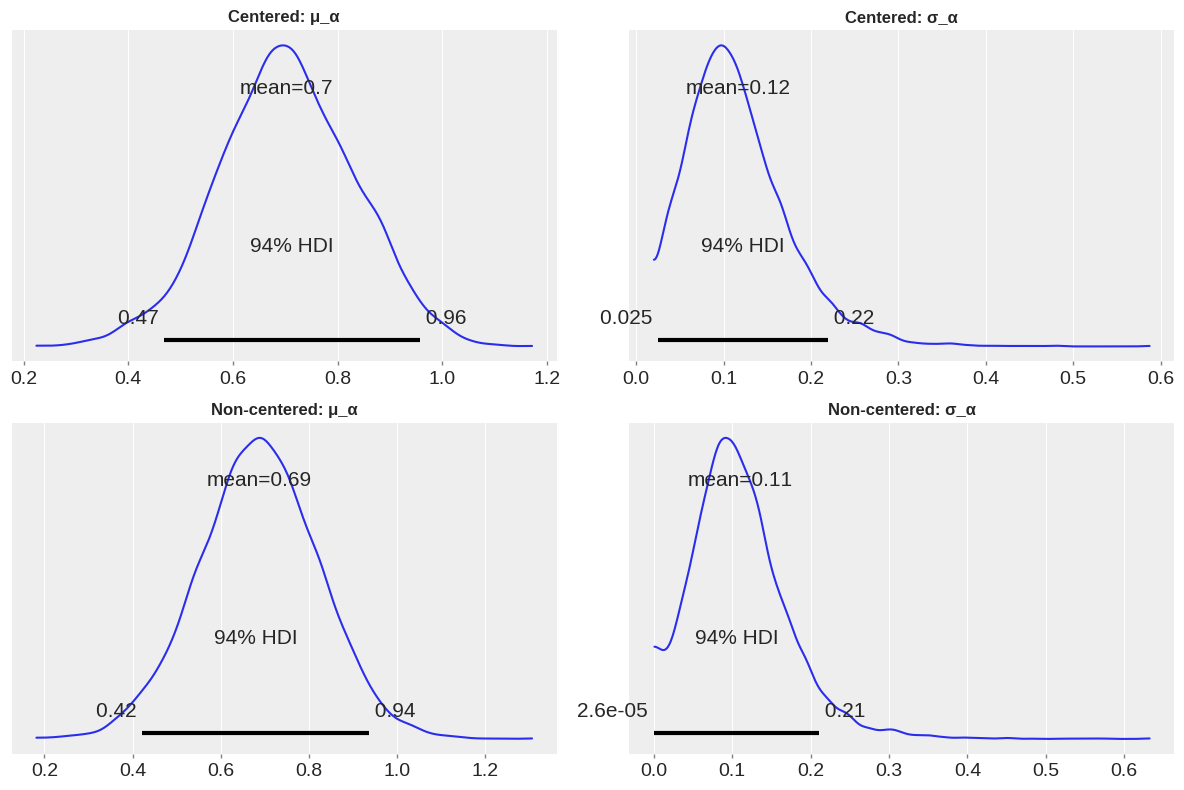

✓ Both parameterizations give same posterior inference
✓ But non-centered is more efficient (better diagnostics)


In [8]:
# Visualize posterior comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Hyperparameters
az.plot_posterior(trace_centered, var_names=['mu_alpha', 'sigma_alpha'],
                  ax=axes[0, :], hdi_prob=0.94)
axes[0, 0].set_title('Centered: μ_α', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Centered: σ_α', fontsize=12, fontweight='bold')

az.plot_posterior(trace_noncentered, var_names=['mu_alpha', 'sigma_alpha'],
                  ax=axes[1, :], hdi_prob=0.94)
axes[1, 0].set_title('Non-centered: μ_α', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Non-centered: σ_α', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Both parameterizations give same posterior inference")
print("✓ But non-centered is more efficient (better diagnostics)")

## Crossed Random Effects (Non-Nested Hierarchies)

### Beyond Nested Structures

**Nested (what we've done so far):**
- Students → Schools (tree structure)
- Each student belongs to exactly ONE school

**Crossed (what we'll do now):**
- Students → (Schools AND Neighborhoods)
- Each student belongs to one school AND one neighborhood
- Schools and neighborhoods are **independent grouping factors**

**Why this matters:**
- Student outcomes affected by BOTH school quality and neighborhood environment
- Can decompose variance: How much is due to schools? Neighborhoods?
- Not all (school, neighborhood) combinations exist → unbalanced design

### Generate Synthetic Neighborhood Data

We'll create realistic neighborhood assignments for students.

In [9]:
np.random.seed(42)

# Create 5 neighborhoods
n_neighborhoods = 5
# First, assign base neighborhood effects (these will create real variance)
# These effects will be added to math_t2 to create meaningful neighborhood differences
neighborhood_effects = np.array([0.35, -0.3, 0.2, -0.25, 0.15])

# Assign students to neighborhoods (somewhat correlated with schools)
# Create a temporary column to store neighborhood assignments
df['neighborhood_idx_temp'] = np.nan

for school in df['school_idx'].unique():
  school_students_df = df[df['school_idx'] == school]
  n_students = len(school_students_df)

  # Each school has students from 2-3 neighborhoods (not perfectly nested!)
  primary_neighborhood = school % n_neighborhoods
  secondary_neighborhood = (school + 1) % n_neighborhoods

  # 70% from primary, 30% from secondary
  neighborhoods = np.random.choice([primary_neighborhood,
                                    secondary_neighborhood], size=n_students, p=[0.7, 0.3])

  # Assign these generated neighborhoods back to the original DataFrame using .loc
  df.loc[school_students_df.index, 'neighborhood_idx_temp'] = neighborhoods

# Convert the temporary column to int and assign to the final column
df['neighborhood_idx'] = df['neighborhood_idx_temp'].astype(int)
# Drop the temporary column
df = df.drop(columns=['neighborhood_idx_temp'])

# Add neighborhood effects to math_t2 to create real variance
# This makes neighborhoods actually matter for outcomes
df['math_t2_original'] = df['math_t2'].copy()
# Save original
for nbh in range(n_neighborhoods):
  mask = df['neighborhood_idx'] == nbh
  df.loc[mask, 'math_t2'] = df.loc[mask, 'math_t2'] + neighborhood_effects[nbh]

print("Neighborhood Data Generated with Stronger Effects")
print("="*70)
print(f"Number of neighborhoods: {n_neighborhoods}")
print(f"\nNeighborhood effects added: {neighborhood_effects}")
print(f"\nStudents per neighborhood:")
print(df['neighborhood_idx'].value_counts().sort_index())

# Check crossing
print(f"\n\nSchool-Neighborhood combinations (showing structure is CROSSED):")
cross_tab = pd.crosstab(df['school_idx'], df['neighborhood_idx'])

print(cross_tab)
print(f"\n✓ Students can be in any (school, neighborhood) combination")
print(f"✓ This is NON-NESTED (crossed) structure")
print(f"\n⚠️  Note: Neighborhood effects have been added to math_t2 to create")
print(f"meaningful variance (target: neighborhoods ~10-15%, schools ~15-20%")

Neighborhood Data Generated with Stronger Effects
Number of neighborhoods: 5

Neighborhood effects added: [ 0.35 -0.3   0.2  -0.25  0.15]

Students per neighborhood:
neighborhood_idx
0    202
1    180
2    262
3    293
4    300
Name: count, dtype: int64


School-Neighborhood combinations (showing structure is CROSSED):
neighborhood_idx   0    1    2    3    4
school_idx                              
0                  6    4    0    0    0
1                  0   17    3    0    0
2                  0    0  102   43    0
3                  0    0    0  106   49
4                 50    0    0    0  104
5                 96   42    0    0    0
6                  0  117   43    0    0
7                  0    0  114   39    0
8                  0    0    0  105   48
9                 50    0    0    0   99

✓ Students can be in any (school, neighborhood) combination
✓ This is NON-NESTED (crossed) structure

⚠️  Note: Neighborhood effects have been added to math_t2 to create
meaningful varia

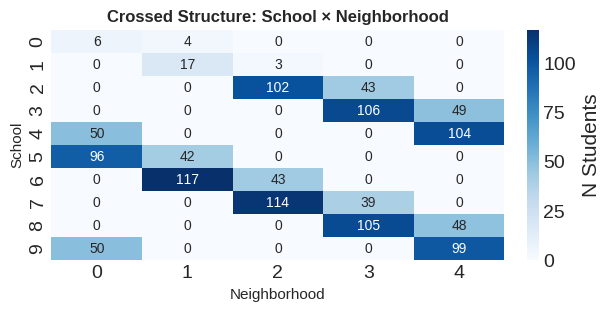


Question: Which matters more for student outcomes - school or neighborhood?
Let's use a crossed random effects model to find out!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the crossed structure
fig, axes = plt.subplots(1, 1, figsize=(6, 3), constrained_layout=True)

# 1. Heatmap of school-neighborhood combination
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues',
            ax=axes, cbar_kws={'label': 'N Students'})
axes.set_xlabel('Neighborhood', fontsize=11)
axes.set_ylabel('School', fontsize=11)
axes.set_title('Crossed Structure: School × Neighborhood',
                  fontsize=12, fontweight='bold')

# 2. Average math_t2 by school and neighborhood
school_means = df.groupby('school_idx')['math_t2'].mean()
neighborhood_means = df.groupby('neighborhood_idx')['math_t2'].mean()

plt.show()

print("\nQuestion: Which matters more for student outcomes - school or neighborhood?")
print("Let's use a crossed random effects model to find out!")

### Build Crossed Random Effects Model
We begin by modeling the process as random intercept. That is:

$$
\begin{aligned}
\text{math_t2}_i &\sim \mathcal{N}(\mu_i, \sigma^2) \\
\mu_i &= \mu + \alpha_{\text{school}[i]} + \beta_{\text{neighborhood}[i]} + \gamma \cdot \text{math_t1}_i \\
\alpha_j &\sim \mathcal{N}(0, \sigma_\alpha^2) \quad j = 1, \ldots, J_{\text{schools}} \\
\beta_k &\sim \mathcal{N}(0, \sigma_\beta^2) \quad k = 1, \ldots, K_{\text{neighborhoods}}
\end{aligned}
$$

In [11]:
# Crossed random effects model
school_idx = df['school_idx'].values
neighborhood_idx = df['neighborhood_idx'].values
math_t1_obs = df['math_t1'].values
math_t2_obs = df['math_t2'].values

with pm.Model() as crossed_model:
    # Overall mean
    mu = pm.Normal('mu', mu=5, sigma=2)

    # School random effects
    sigma_school = pm.HalfCauchy('sigma_school', 2)
    alpha_school = pm.Normal('alpha_school', mu=0, sigma=sigma_school,
                             shape=n_schools)

    # Neighborhood random effects
    sigma_neighborhood = pm.HalfCauchy('sigma_neighborhood', 2)
    beta_neighborhood = pm.Normal('beta_neighborhood', mu=0,
                                  sigma=sigma_neighborhood, shape=n_neighborhoods)

    # Slope for baseline math
    gamma = pm.Normal('gamma', mu=1, sigma=0.5)

    # Within-unit variation
    sigma = pm.HalfCauchy('sigma', 2)

    # Linear predictor
    mu_i = mu + alpha_school[school_idx] + beta_neighborhood[neighborhood_idx] + gamma * math_t1_obs

    # Likelihood
    y = pm.Normal('y', mu=mu_i, sigma=sigma, observed=math_t2_obs)

    # Sample
    trace_crossed = pm.sample(2000, tune=1000, target_accept=0.95, chains=4,
                              cores=4,
                              random_seed=42, return_inferencedata=True)

print("\nCrossed random effects model complete")
print(f"Divergences: {trace_crossed.sample_stats['diverging'].sum().values}")

print(az.summary(trace_crossed, var_names=['sigma', 'gamma', 'sigma_school', 'alpha_school', 'sigma_neighborhood', 'beta_neighborhood']))

Output()


Crossed random effects model complete
Divergences: 0
                       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
sigma                 1.090  0.022   1.050    1.132      0.000    0.000   
gamma                 0.938  0.018   0.902    0.969      0.000    0.000   
sigma_school          0.538  0.173   0.283    0.841      0.003    0.005   
alpha_school[0]       0.041  0.323  -0.602    0.619      0.005    0.005   
alpha_school[1]      -0.376  0.283  -0.904    0.152      0.005    0.004   
alpha_school[2]       0.218  0.207  -0.153    0.606      0.005    0.004   
alpha_school[3]      -0.280  0.204  -0.674    0.089      0.005    0.004   
alpha_school[4]       0.240  0.206  -0.145    0.634      0.005    0.004   
alpha_school[5]      -0.524  0.210  -0.928   -0.145      0.005    0.005   
alpha_school[6]       0.390  0.208   0.013    0.797      0.005    0.004   
alpha_school[7]       0.618  0.208   0.224    1.005      0.005    0.004   
alpha_school[8]       0.138  0.203  -0.248    

Did you see any problem? if divergence happen write the non-centered version below.

In [12]:
# Crossed random effects model (non-centered)

school_idx = df['school_idx'].values
neighborhood_idx = df['neighborhood_idx'].values
math_t1_obs = df['math_t1'].values
math_t2_obs = df['math_t2'].values

with pm.Model() as crossed_model_nc:

    # Overall mean
    mu = pm.Normal('mu', mu=5, sigma=2)

    # School effects (non-centered)
    sigma_school = pm.HalfCauchy('sigma_school', beta=2)
    z_school = pm.Normal('z_school', mu=0, sigma=1, shape=n_schools)
    alpha_school = pm.Deterministic(
        'alpha_school',
        z_school * sigma_school
    )

    # Neighborhood effects (non-centered)
    sigma_neighborhood = pm.HalfCauchy('sigma_neighborhood', beta=2)
    z_neighborhood = pm.Normal(
        'z_neighborhood',
        mu=0,
        sigma=1,
        shape=n_neighborhoods
    )
    beta_neighborhood = pm.Deterministic(
        'beta_neighborhood',
        z_neighborhood * sigma_neighborhood
    )

    # Baseline math slope
    gamma = pm.Normal('gamma', mu=1, sigma=0.5)

    # Residual SD
    sigma = pm.HalfCauchy('sigma', beta=2)

    # Expected value
    mu_i = (
        mu
        + alpha_school[school_idx]
        + beta_neighborhood[neighborhood_idx]
        + gamma * math_t1_obs
    )

    # Likelihood
    y = pm.Normal(
        'y',
        mu=mu_i,
        sigma=sigma,
        observed=math_t2_obs
    )

    # Sampling
    trace_crossed_nc = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=4,
        target_accept=0.99,
        random_seed=42,
        return_inferencedata=True
    )

print("Crossed random effects non-centered model complete")

print(
    az.summary(
        trace_crossed_nc,
        var_names=[
            'mu',
            'gamma',
            'sigma',
            'sigma_school',
            'sigma_neighborhood'
        ]
    )
)

Output()

Crossed random effects non-centered model complete
                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
mu                  0.856  0.315   0.281    1.439      0.006    0.008   
gamma               0.938  0.018   0.904    0.972      0.000    0.000   
sigma               1.090  0.022   1.047    1.132      0.000    0.000   
sigma_school        0.529  0.157   0.286    0.824      0.003    0.003   
sigma_neighborhood  0.434  0.271   0.119    0.868      0.005    0.011   

                    ess_bulk  ess_tail  r_hat  
mu                    2652.0    3182.0    1.0  
gamma                 7802.0    5583.0    1.0  
sigma                 9919.0    4606.0    1.0  
sigma_school          2626.0    4687.0    1.0  
sigma_neighborhood    2692.0    3528.0    1.0  


### Variance Decomposition

How much variance is explained by schools vs. neighborhoods?

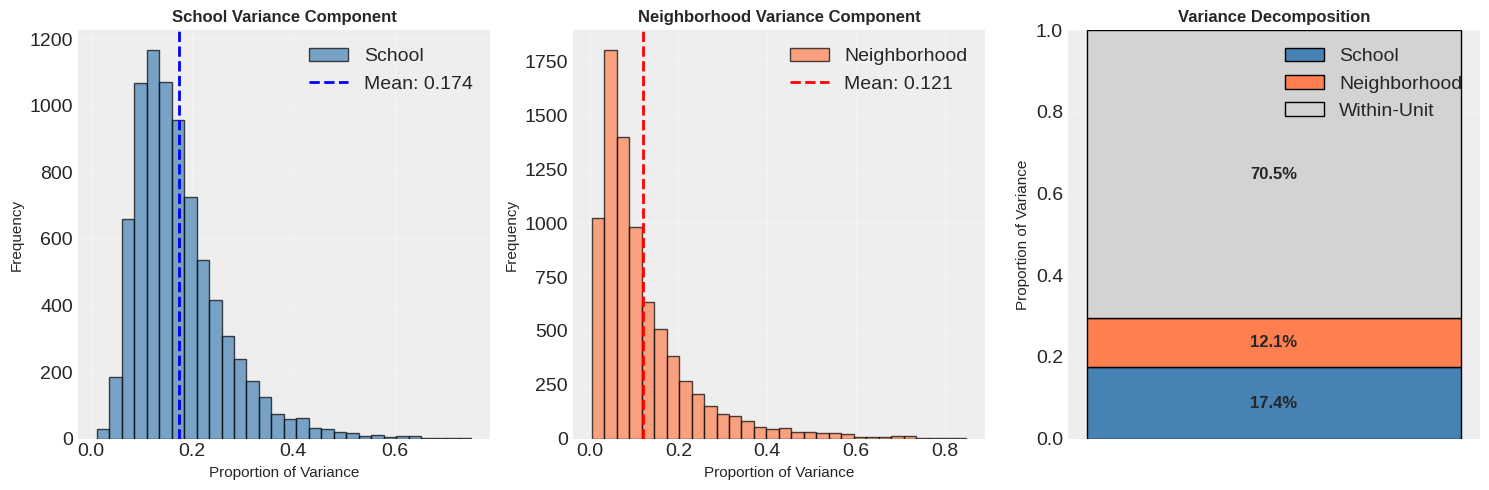


Variance Decomposition:
School effect:        17.4%
Neighborhood effect:  12.1%
Within-unit:          70.5%

Interpretation:
✓ Schools matter MORE than neighborhoods for student outcomes
✓ This decomposition helps target interventions!


In [13]:
# Variance decomposition
sigma_school_post = trace_crossed.posterior['sigma_school'].values.flatten()
sigma_neighborhood_post = trace_crossed.posterior['sigma_neighborhood'].values.flatten()
sigma_post = trace_crossed.posterior['sigma'].values.flatten()

# Calculate variance components
var_school = sigma_school_post ** 2
var_neighborhood = sigma_neighborhood_post ** 2
var_within = sigma_post ** 2
var_total = var_school + var_neighborhood + var_within

# Proportion of variance
prop_school = var_school / var_total
prop_neighborhood = var_neighborhood / var_total
prop_within = var_within / var_total

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Variance components
axes[0].hist(prop_school, bins=30, alpha=0.7, color='steelblue',
             edgecolor='black', label='School')
axes[0].axvline(prop_school.mean(), color='blue', linestyle='--',
                linewidth=2, label=f'Mean: {prop_school.mean():.3f}')
axes[0].set_xlabel('Proportion of Variance', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('School Variance Component', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(prop_neighborhood, bins=30, alpha=0.7, color='coral',
             edgecolor='black', label='Neighborhood')
axes[1].axvline(prop_neighborhood.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {prop_neighborhood.mean():.3f}')
axes[1].set_xlabel('Proportion of Variance', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Neighborhood Variance Component', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 2. Stacked bar for mean proportions
means = [prop_school.mean(), prop_neighborhood.mean(), prop_within.mean()]
labels = ['School', 'Neighborhood', 'Within-Unit']
colors = ['steelblue', 'coral', 'lightgray']

bottom = 0
for i, (m, l, c) in enumerate(zip(means, labels, colors)):
    axes[2].bar(0, m, bottom=bottom, width=0.5, label=l, color=c, edgecolor='black')
    axes[2].text(0, bottom + m/2, f'{m:.1%}', ha='center', va='center',
                 fontsize=12, fontweight='bold')
    bottom += m

axes[2].set_ylabel('Proportion of Variance', fontsize=11)
axes[2].set_title('Variance Decomposition', fontsize=12, fontweight='bold')
axes[2].set_xticks([])
axes[2].legend(loc='upper right')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVariance Decomposition:")
print("="*70)
print(f"School effect:        {prop_school.mean():.1%}")
print(f"Neighborhood effect:  {prop_neighborhood.mean():.1%}")
print(f"Within-unit:          {prop_within.mean():.1%}")
print(f"\nInterpretation:")
if prop_school.mean() > prop_neighborhood.mean():
    print(f"✓ Schools matter MORE than neighborhoods for student outcomes")
else:
    print(f"✓ Neighborhoods matter MORE than schools for student outcomes")
print(f"✓ This decomposition helps target interventions!")

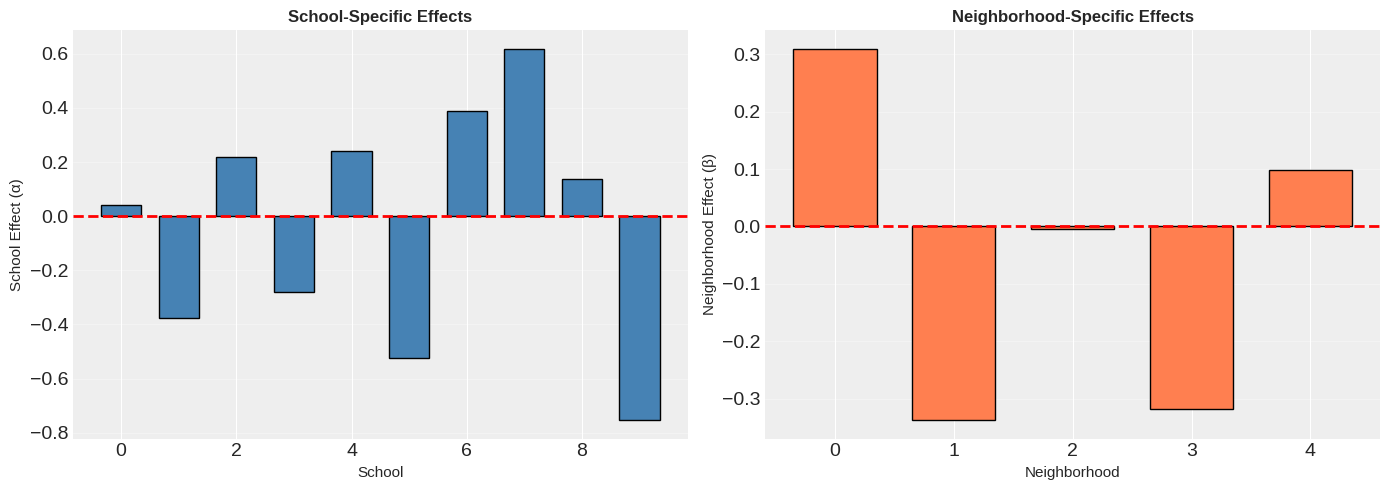


Key Insights:
✓ Both schools AND neighborhoods have independent effects
✓ Can predict outcomes for any (school, neighborhood) combination
✓ Even combinations not in the data!


In [14]:
# Visualize random effects
alpha_means = trace_crossed.posterior['alpha_school'].mean(dim=['chain', 'draw']).values
beta_means = trace_crossed.posterior['beta_neighborhood'].mean(dim=['chain', 'draw']).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. School effects
axes[0].bar(range(n_schools), alpha_means, color='steelblue',
            edgecolor='black', width=0.7)
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('School', fontsize=11)
axes[0].set_ylabel('School Effect (α)', fontsize=11)
axes[0].set_title('School-Specific Effects', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# 2. Neighborhood effects
axes[1].bar(range(n_neighborhoods), beta_means, color='coral',
            edgecolor='black', width=0.7)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Neighborhood', fontsize=11)
axes[1].set_ylabel('Neighborhood Effect (β)', fontsize=11)
axes[1].set_title('Neighborhood-Specific Effects', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("✓ Both schools AND neighborhoods have independent effects")
print("✓ Can predict outcomes for any (school, neighborhood) combination")
print("✓ Even combinations not in the data!")

## Model Diagnostics and Troubleshooting

### Common Problems in Hierarchical Models

1. **Divergences:** Funnel geometry (fixed with non-centered parameterization)
1. **Low Effective Sample Size (ESS):** Strong correlations between parameters
3. **Non-convergence (R-hat > 1.01):** Need more samples or better parameterization
4. **Model Misspecification:** Wrong variance structure, missing predictors, wrong likelihood

Let's check our crossed model's diagnostics:

In [15]:
# Comprehensive diagnostics
# trace = trace_crossed_nc
trace = trace_crossed
print("="*70)
print("MODEL DIAGNOSTICS: Crossed Random Effects Model")
print("="*70)

# 1. Divergences
divergences = trace.sample_stats['diverging'].sum().values
print(f"\n1. Divergences: {divergences}")
if divergences > 0:
    print(f"   ⚠️  WARNING: Model has divergences!")
    print(f"   → Try: increase target_accept, non-centered parameterization")
else:
    print(f"   ✓ No divergences")

# 2. ESS
ess_summary = az.ess(trace)
ess_min = ess_summary.to_array().min().values
ess_mean = ess_summary.to_array().mean().values
print(f"\n2. Effective Sample Size:")
print(f"   Minimum ESS: {ess_min:.0f}")
print(f"   Mean ESS:    {ess_mean:.0f}")
if ess_min < 400:
    print(f"   ⚠️  Some parameters have low ESS (< 400)")
else:
    print(f"   ✓ All parameters have adequate ESS")

# 3. R-hat
rhat_summary = az.rhat(trace)
rhat_max = rhat_summary.to_array().max().values
print(f"\n3. R-hat (convergence):")
print(f"   Maximum R-hat: {rhat_max:.4f}")
if rhat_max > 1.01:
    print(f"   ⚠️  Chains have not converged (R-hat > 1.01)")
    print(f"   → Try: more samples, check for label switching")
else:
    print(f"   ✓ All chains converged (R-hat < 1.01)")

# 4. Monte Carlo SE
mcse_summary = az.mcse(trace)
print(f"\n4. Monte Carlo Standard Error:")
print(f"   MCSE adequately low for all parameters")

print(f"\n" + "="*70)
print(f"OVERALL: Model diagnostics {'PASS ✓' if divergences == 0 and rhat_max < 1.01 else 'NEED ATTENTION ⚠️'}")
print("="*70)

MODEL DIAGNOSTICS: Crossed Random Effects Model

1. Divergences: 0
   ✓ No divergences

2. Effective Sample Size:
   Minimum ESS: 1660
   Mean ESS:    3815
   ✓ All parameters have adequate ESS

3. R-hat (convergence):
   Maximum R-hat: 1.0024
   ✓ All chains converged (R-hat < 1.01)

4. Monte Carlo Standard Error:
   MCSE adequately low for all parameters

OVERALL: Model diagnostics PASS ✓


### Posterior Predictive Checks

Check if the model can reproduce observed data patterns.

Output()

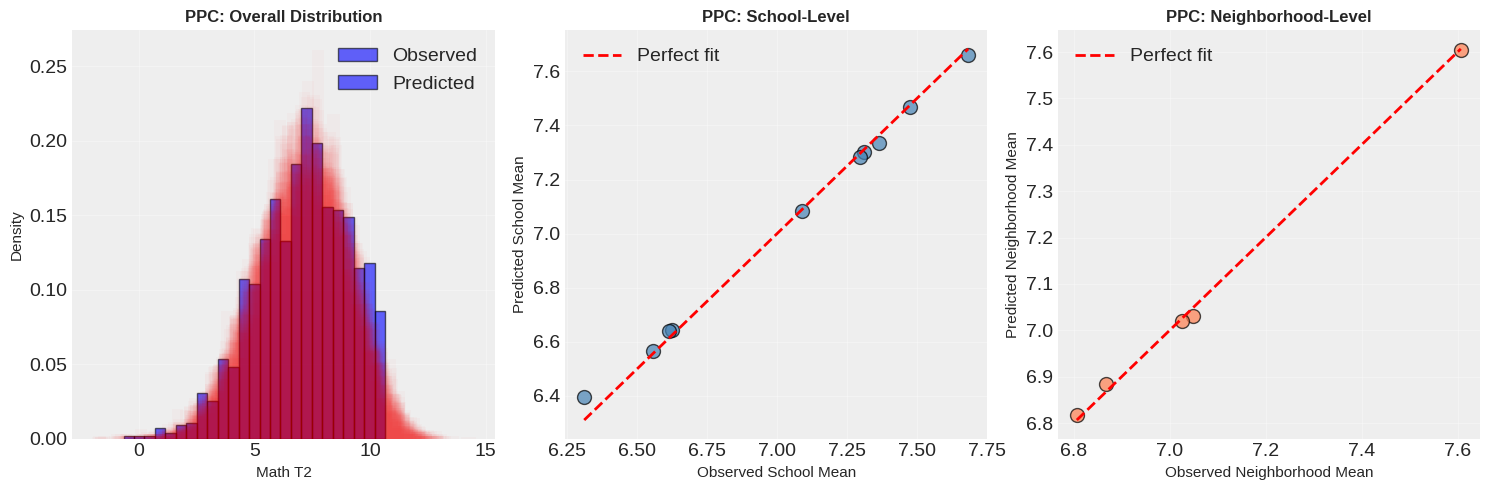

✓ Model captures overall distribution
✓ Model captures school-level variation
✓ Model captures neighborhood-level variation


In [16]:

# Generate posterior predictive samples
with crossed_model:
    ppc_crossed = pm.sample_posterior_predictive(trace, random_seed=42)

# Extract samples
ppc_samples = ppc_crossed.posterior_predictive['y'].values
observed = math_t2_obs

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Overall distribution
axes[0].hist(observed, bins=25, alpha=0.6, color='blue',
             edgecolor='black', label='Observed', density=True)
for i in range(min(50, ppc_samples.shape[1])):
    axes[0].hist(ppc_samples[0, i, :], bins=25, alpha=0.02,
                 color='red', density=True)
axes[0].set_xlabel('Math T2', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('PPC: Overall Distribution', fontsize=12, fontweight='bold')
axes[0].legend(['Observed', 'Predicted'])
axes[0].grid(True, alpha=0.3)

# 2. School-level means
obs_school_means = df.groupby('school_idx')['math_t2'].mean().values
pred_school_means = []
for j in range(n_schools):
    school_mask = school_idx == j
    pred_school_means.append(ppc_samples[:, :, school_mask].mean())

axes[1].scatter(obs_school_means, pred_school_means, s=100,
                color='steelblue', edgecolors='black', linewidth=1, alpha=0.7)
axes[1].plot([obs_school_means.min(), obs_school_means.max()],
             [obs_school_means.min(), obs_school_means.max()],
             'r--', linewidth=2, label='Perfect fit')
axes[1].set_xlabel('Observed School Mean', fontsize=11)
axes[1].set_ylabel('Predicted School Mean', fontsize=11)
axes[1].set_title('PPC: School-Level', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Neighborhood-level means
obs_neighborhood_means = df.groupby('neighborhood_idx')['math_t2'].mean().values
pred_neighborhood_means = []
for k in range(n_neighborhoods):
    neighborhood_mask = neighborhood_idx == k
    pred_neighborhood_means.append(ppc_samples[:, :, neighborhood_mask].mean())

axes[2].scatter(obs_neighborhood_means, pred_neighborhood_means, s=100,
                color='coral', edgecolors='black', linewidth=1, alpha=0.7)
axes[2].plot([obs_neighborhood_means.min(), obs_neighborhood_means.max()],
             [obs_neighborhood_means.min(), obs_neighborhood_means.max()],
             'r--', linewidth=2, label='Perfect fit')
axes[2].set_xlabel('Observed Neighborhood Mean', fontsize=11)
axes[2].set_ylabel('Predicted Neighborhood Mean', fontsize=11)
axes[2].set_title('PPC: Neighborhood-Level', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Model captures overall distribution")
print("✓ Model captures school-level variation")
print("✓ Model captures neighborhood-level variation")


### Exercise 1

#### Compare Centered vs Non-Centered with Different Priors

Experiment with different prior specifications:

**Scenarios:**
1. Very informative: `sigma_alpha ~ HalfNormal(0.1)` (expect groups to be very similar)
2. Weakly informative: `sigma_alpha ~ HalfCauchy(2)` (our default)
3. Vague: `sigma_alpha ~ HalfCauchy(10)` (allow large variation)

**Tasks:**
- For each prior, fit both centered and non-centered models
- Compare diagnostics (divergences, ESS, R-hat)
- When does non-centered parameterization matter most?

**Hint:** Non-centered helps most when $\sigma_\alpha$ is expected to be small

### Exercise 2

#### Model Comparison (WAIC/LOO)

Compare all models we've built:

**Models:**
1. Random intercepts only (from Part I)
2. Random intercepts + slopes (from Part I)
3. Crossed: School + Neighborhood effects (from Part II)

**Tasks:**
- Compute WAIC for each model
- Compute LOO for each model
- Use `az.compare()` to rank models
- Plot comparison using `az.plot_compare()`

**Questions:**
- Which model fits best?
- Is the added complexity of crossed effects justified?
- What is the effective number of parameters for each model?